In [ ]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
# ==========================================
# Traffic Signal Timing Optimization Using AI Deep Learning
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)

All libraries imported successfully!
TensorFlow Version: 2.21.0


In [ ]:
import os

# Search for Traffic.csv in your Downloads folder
for root, dirs, files in os.walk(r"C:\Users\gayat\Downloads"):
    for file in files:
        if file.lower() == "traffic.csv":
            print(os.path.join(root, file))

C:\Users\gayat\Downloads\TFOP_dataset\Traffic.csv


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\gayat\Downloads\TFOP_dataset\Traffic.csv")

# Display the first 5 rows
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [2]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# General information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2976, 9)

Columns:
Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='str')

Data Types:
Time                   str
Date                 int64
Day of the week        str
CarCount             int64
BikeCount            int64
BusCount             int64
TruckCount           int64
Total                int64
Traffic Situation      str
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Time               2976 non-null   str  
 1   Date               2976 non-null   int64
 2   Day of the week    2976 non-null   str  
 3   CarCount           2976 non-null   int64
 4   BikeCount          2976 non-null   int64
 5   BusCount           2976 non-null   int64
 6   TruckCount         2976 non-null   int64
 7   Total    

In [3]:
# Statistical summary of numerical columns
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [4]:
# Check unique values in each column
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Time
<StringArray>
['12:00:00 AM', '12:15:00 AM', '12:30:00 AM', '12:45:00 AM',  '1:00:00 AM',
  '1:15:00 AM',  '1:30:00 AM',  '1:45:00 AM',  '2:00:00 AM',  '2:15:00 AM',
  '2:30:00 AM',  '2:45:00 AM',  '3:00:00 AM',  '3:15:00 AM',  '3:30:00 AM',
  '3:45:00 AM',  '4:00:00 AM',  '4:15:00 AM',  '4:30:00 AM',  '4:45:00 AM',
  '5:00:00 AM',  '5:15:00 AM',  '5:30:00 AM',  '5:45:00 AM',  '6:00:00 AM',
  '6:15:00 AM',  '6:30:00 AM',  '6:45:00 AM',  '7:00:00 AM',  '7:15:00 AM',
  '7:30:00 AM',  '7:45:00 AM',  '8:00:00 AM',  '8:15:00 AM',  '8:30:00 AM',
  '8:45:00 AM',  '9:00:00 AM',  '9:15:00 AM',  '9:30:00 AM',  '9:45:00 AM',
 '10:00:00 AM', '10:15:00 AM', '10:30:00 AM', '10:45:00 AM', '11:00:00 AM',
 '11:15:00 AM', '11:30:00 AM', '11:45:00 AM', '12:00:00 PM', '12:15:00 PM',
 '12:30:00 PM', '12:45:00 PM',  '1:00:00 PM',  '1:15:00 PM',  '1:30:00 PM',
  '1:45:00 PM',  '2:00:00 PM',  '2:15:00 PM',  '2:30:00 PM',  '2:45:00 PM',
  '3:00:00 PM',  '3:15:00 PM',  '3:30:00 PM',  '3:45:00 PM',  '4:00:

In [5]:

# Count of each traffic situation
print(df["Traffic Situation"].value_counts())

Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64


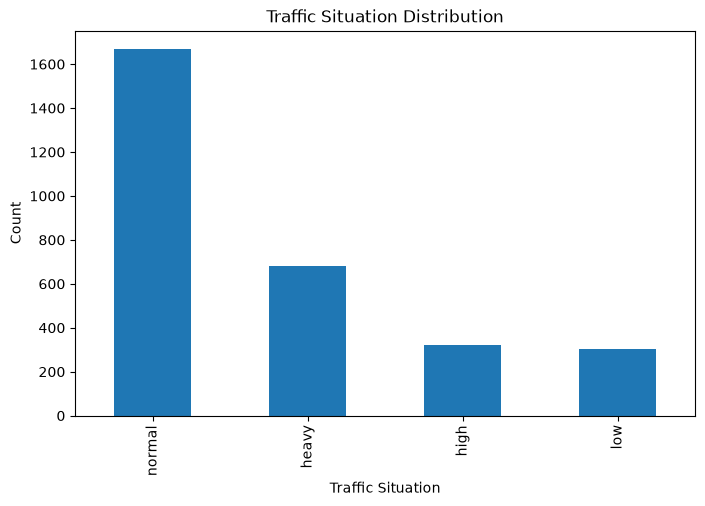

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["Traffic Situation"].value_counts().plot(kind="bar")
plt.title("Traffic Situation Distribution")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.show()

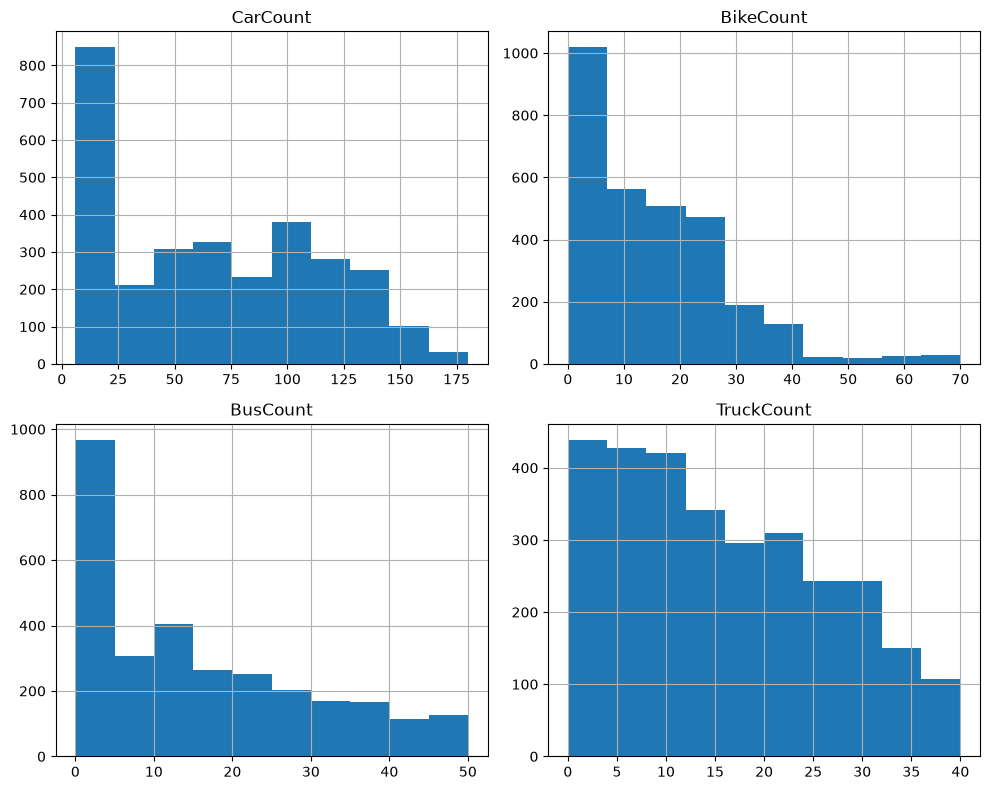

In [9]:
vehicle_columns = ["CarCount", "BikeCount", "BusCount", "TruckCount"]

df[vehicle_columns].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [8]:
print(df.columns)

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='str')


In [10]:
print(df.head())

          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  


In [11]:
# Convert Time to datetime
df["Time"] = pd.to_datetime(df["Time"], format="%I:%M:%S %p")

# Create Hour feature
df["Hour"] = df["Time"].dt.hour

# Verify
df[["Time", "Hour"]].head()

,Time,Hour
0,1900-01-01 00:00:00,0
1,1900-01-01 00:15:00,0
2,1900-01-01 00:30:00,0
3,1900-01-01 00:45:00,0
4,1900-01-01 01:00:00,1


In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode Day of the week
day_encoder = LabelEncoder()
df["Day of the week"] = day_encoder.fit_transform(df["Day of the week"])

# Encode Traffic Situation
traffic_encoder = LabelEncoder()
df["Traffic Situation"] = traffic_encoder.fit_transform(df["Traffic Situation"])

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,1900-01-01 00:00:00,10,5,31,0,4,4,39,2,0
1,1900-01-01 00:15:00,10,5,49,0,3,3,55,2,0
2,1900-01-01 00:30:00,10,5,46,0,3,6,55,2,0
3,1900-01-01 00:45:00,10,5,51,0,2,5,58,2,0
4,1900-01-01 01:00:00,10,5,57,6,15,16,94,3,1


In [13]:
X = df[[
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount",
    "Total",
    "Hour",
    "Day of the week"
]]

y = df["Traffic Situation"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2976, 7)
Target Shape: (2976,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (2380, 7)
Testing Data : (596, 7)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create the model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(len(set(y)), activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

c:\Users\gayat\Traffic_AI_Project\traffic_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,724 (10.64 KB)

 Trainable params: 2,724 (10.64 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6560 - loss: 0.9978 - val_accuracy: 0.7332 - val_loss: 0.7425
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7416 - loss: 0.7061 - val_accuracy: 0.7731 - val_loss: 0.5662
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7925 - loss: 0.5514 - val_accuracy: 0.8445 - val_loss: 0.4447
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8440 - loss: 0.4605 - val_accuracy: 0.8676 - val_loss: 0.3665
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8482 - loss: 0.4083 - val_accuracy: 0.8739 - val_loss: 0.3247
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8619 - loss: 0.3780 - val_accuracy: 0.8824 - val_loss: 0.2969
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8703 - loss: 0.3448 - val_accuracy: 0.8761 - val_loss: 0.2820
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8739 - loss: 0.3346 - val_accuracy: 0.8782 - val_loss

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9262 - loss: 0.1916
Test Loss : 0.1916002482175827
Test Accuracy : 0.926174521446228


In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9235 - loss: 0.2015 - val_accuracy: 0.9362 - val_loss: 0.1776
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9231 - loss: 0.1963 - val_accuracy: 0.9312 - val_loss: 0.1784
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9244 - loss: 0.1947 - val_accuracy: 0.9430 - val_loss: 0.1697
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9353 - loss: 0.1852 - val_accuracy: 0.9379 - val_loss: 0.1696
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9315 - loss: 0.1825 - val_accuracy: 0.9413 - val_loss: 0.1628
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9382 - loss: 0.1753 - val_accuracy: 0.9329 - val_loss: 0.1685
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9290 - loss: 0.1893 - val_accuracy: 0.9413 - val_loss: 0.1609
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9349 - loss: 0.1725 - val_accuracy: 0.9430 - val_loss:

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
 1/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9688 - loss: 0.0583

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9513 - loss: 0.1350 - val_accuracy: 0.9513 - val_loss: 0.1203
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9542 - loss: 0.1359 - val_accuracy: 0.9547 - val_loss: 0.1153
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9542 - loss: 0.1355 - val_accuracy: 0.9497 - val_loss: 0.1133
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9559 - loss: 0.1351 - val_accuracy: 0.9497 - val_loss: 0.1119
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9538 - loss: 0.1320 - val_accuracy: 0.9564 - val_loss: 0.1100
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9563 - loss: 0.1306 - val_accuracy: 0.9597 - val_loss: 0.1108
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9567 - loss: 0.1288 - val_accuracy: 0.9513 - val_loss: 0.1146
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9513 - loss: 0.1354 - val_accuracy: 0.9547 - val_loss: 0.1091
Epo

In [21]:
# Predict probabilities for the test set
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:10])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[1 0 2 2 3 2 0 2 3 3]


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9697986577181208

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       137
           1       0.92      0.89      0.90        64
           2       1.00      0.95      0.97        61
           3       0.98      0.98      0.98       334

    accuracy                           0.97       596
   macro avg       0.96      0.95      0.96       596
weighted avg       0.97      0.97      0.97       596


Confusion Matrix
[[135   2   0   0]
 [  3  57   0   4]
 [  0   0  58   3]
 [  3   3   0 328]]


In [23]:
# Example input
new_data = [[80, 20, 10, 5, 115, 18, 1]]
# [CarCount, BikeCount, BusCount, TruckCount, Total, Hour, Day of the week]

# Scale the input
new_data = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data)

predicted_class = np.argmax(prediction, axis=1)[0]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

c:\Users\gayat\Traffic_AI_Project\traffic_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Class: 3


In [24]:
predicted_traffic = traffic_encoder.inverse_transform([predicted_class])[0]

print("Predicted Traffic Situation:", predicted_traffic)

Predicted Traffic Situation: normal


In [25]:
if predicted_traffic == "low":
    green_time = 20

elif predicted_traffic == "normal":
    green_time = 40

elif predicted_traffic == "high":
    green_time = 60

elif predicted_traffic == "heavy":
    green_time = 90

else:
    green_time = 30

print("Traffic Situation :", predicted_traffic)
print("Recommended Green Signal Time :", green_time, "seconds")

Traffic Situation : normal
Recommended Green Signal Time : 40 seconds


In [26]:
# Total number of vehicles
total_vehicles = 80 + 20 + 10 + 5   # Replace these with your input values if needed

# Dynamic Green Signal Timing
if predicted_traffic == "low":
    green_time = 20 + (total_vehicles * 0.10)

elif predicted_traffic == "normal":
    green_time = 35 + (total_vehicles * 0.15)

elif predicted_traffic == "high":
    green_time = 50 + (total_vehicles * 0.20)

elif predicted_traffic == "heavy":
    green_time = 70 + (total_vehicles * 0.25)

# Limit between 20 and 120 seconds
green_time = max(20, min(120, green_time))

print("Traffic Situation :", predicted_traffic)
print("Total Vehicles :", total_vehicles)
print("Recommended Green Signal Time :", round(green_time), "seconds")

Traffic Situation : normal
Total Vehicles : 115
Recommended Green Signal Time : 52 seconds


In [27]:
# Save the trained model
model.save("Traffic_Signal_Optimization_Model.keras")

print("Model saved successfully!")

Model saved successfully!


In [28]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [29]:
joblib.dump(traffic_encoder, "traffic_encoder.pkl")

print("Traffic encoder saved successfully!")

Traffic encoder saved successfully!


In [30]:
# Example input
car = 120
bike = 35
bus = 15
truck = 10
hour = 18
day = 1

total = car + bike + bus + truck

sample = [[car, bike, bus, truck, total, hour, day]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

predicted_traffic = traffic_encoder.inverse_transform([predicted_class])[0]

print("Predicted Traffic:", predicted_traffic)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

c:\Users\gayat\Traffic_AI_Project\traffic_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Traffic: heavy


In [31]:
if predicted_traffic == "low":
    green_time = 20 + total * 0.10
elif predicted_traffic == "normal":
    green_time = 35 + total * 0.15
elif predicted_traffic == "high":
    green_time = 50 + total * 0.20
else:  # heavy
    green_time = 70 + total * 0.25

green_time = round(max(20, min(120, green_time)))

print("\n========== TRAFFIC SIGNAL OPTIMIZATION ==========")
print("Cars              :", car)
print("Bikes             :", bike)
print("Buses             :", bus)
print("Trucks            :", truck)
print("Total Vehicles    :", total)
print("Predicted Traffic :", predicted_traffic)
print("Green Signal Time :", green_time, "seconds")
print("===============================================")


========== TRAFFIC SIGNAL OPTIMIZATION ==========
Cars              : 120
Bikes             : 35
Buses             : 15
Trucks            : 10
Total Vehicles    : 180
Predicted Traffic : heavy
Green Signal Time : 115 seconds


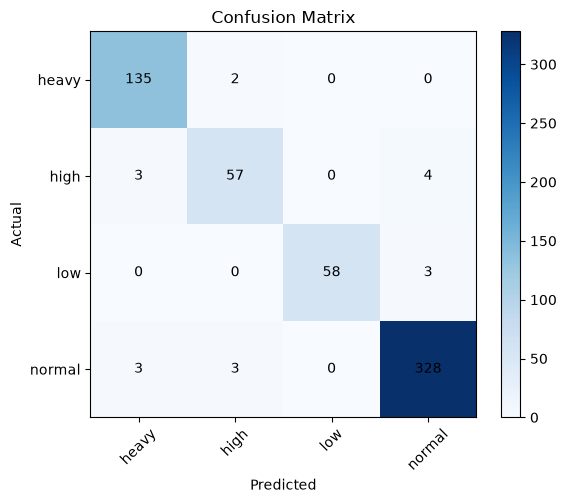

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = traffic_encoder.classes_
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()
plt.show()

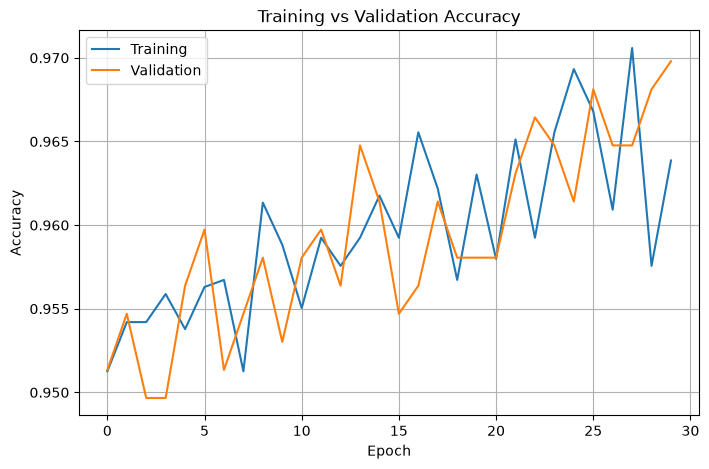

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.grid(True)

plt.show()

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9627 - loss: 0.1112 - val_accuracy: 0.9895 - val_loss: 0.0450
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9716 - loss: 0.1003 - val_accuracy: 0.9958 - val_loss: 0.0403
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9632 - loss: 0.1128 - val_accuracy: 0.9916 - val_loss: 0.0406
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9648 - loss: 0.1033 - val_accuracy: 0.9937 - val_loss: 0.0393
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9611 - loss: 0.1174 - val_accuracy: 0.9937 - val_loss: 0.0415
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9659 - loss: 0.1103 - val_accuracy: 0.9916 - val_loss: 0.0430
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9622 - loss: 0.1113 - val_accuracy: 0.9895 - val_loss: 0.0474
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9685 - loss: 0.1048 - val_accuracy: 0.9937 - val_loss: 0.0415
Epo

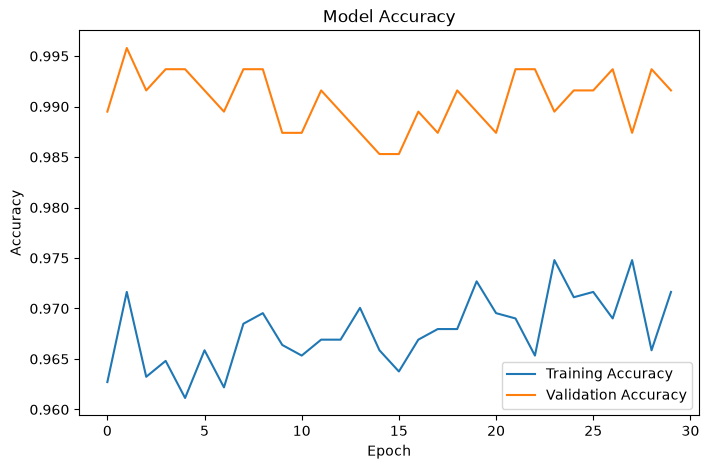

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

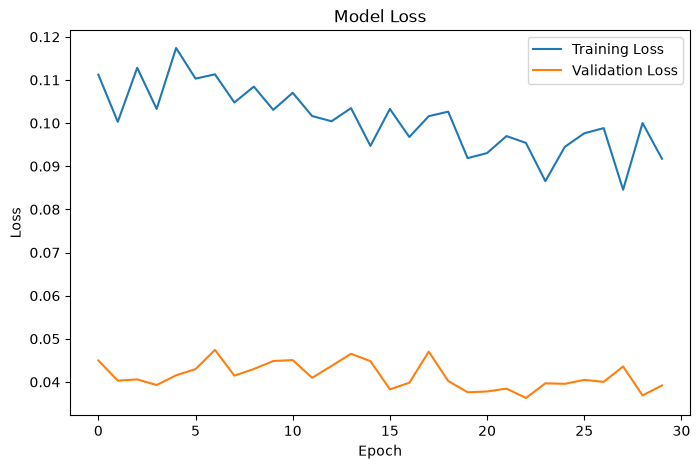

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [37]:
model.save("Traffic_Signal_Optimization_Model.keras")

print("Deep Learning Model Saved Successfully")

Deep Learning Model Saved Successfully


In [38]:
print("="*60)
print("PROJECT COMPLETED")
print("="*60)

print("Project Title:")
print("Traffic Signal Timing Optimization Using AI Deep Learning")

print("\nProject Features")
print("----------------------------")
print("✔ Traffic Data Analysis")
print("✔ Deep Learning Classification")
print("✔ Traffic Prediction")
print("✔ Dynamic Signal Timing Optimization")
print("✔ Model Evaluation")
print("✔ Model Saving")

print("\nStatus : SUCCESSFULLY COMPLETED")

PROJECT COMPLETED
Project Title:
Traffic Signal Timing Optimization Using AI Deep Learning

Project Features
----------------------------
✔ Traffic Data Analysis
✔ Deep Learning Classification
✔ Traffic Prediction
✔ Dynamic Signal Timing Optimization
✔ Model Evaluation
✔ Model Saving

Status : SUCCESSFULLY COMPLETED


In [39]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history.csv", index=False)

print("Training history saved successfully!")

Training history saved successfully!


In [40]:
results = pd.DataFrame({
    "Actual": traffic_encoder.inverse_transform(y_test),
    "Predicted": traffic_encoder.inverse_transform(y_pred)
})

results.head()

,Actual,Predicted
0,high,high
1,heavy,heavy
2,low,low
3,low,low
4,normal,normal


In [41]:
results.to_csv("prediction_results.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [42]:
print("="*70)
print("      TRAFFIC SIGNAL TIMING OPTIMIZATION USING AI DEEP LEARNING")
print("="*70)

print(f"Dataset Size            : {df.shape[0]} rows")
print(f"Features Used           : {X.shape[1]}")
print(f"Traffic Classes         : {list(traffic_encoder.classes_)}")
print(f"Test Accuracy           : {accuracy*100:.2f}%")
print(f"Recommended Green Time  : {green_time} seconds")

print("="*70)
print("Project Status : COMPLETED")
print("="*70)

      TRAFFIC SIGNAL TIMING OPTIMIZATION USING AI DEEP LEARNING
Dataset Size            : 2976 rows
Features Used           : 7
Traffic Classes         : ['heavy', 'high', 'low', 'normal']
Test Accuracy           : 92.62%
Recommended Green Time  : 115 seconds
Project Status : COMPLETED


In [43]:
model.save("traffic_signal_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [44]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [45]:
joblib.dump(traffic_encoder, "traffic_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [46]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

In [47]:
model = load_model("Traffic_Signal_Optimization_Model.keras")

scaler = joblib.load("scaler.pkl")

traffic_encoder = joblib.load("traffic_encoder.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [48]:
sample = [[120, 40, 15, 10, 185, 18, 1]]

In [49]:
sample_scaled = scaler.transform(sample)

c:\Users\gayat\Traffic_AI_Project\traffic_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
prediction = model.predict(sample_scaled)

predicted_class = np.argmax(prediction)

predicted_traffic = traffic_encoder.inverse_transform([predicted_class])[0]

print("Predicted Traffic Situation:", predicted_traffic)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Predicted Traffic Situation: heavy


In [57]:
total = sample[0][4]   # Total vehicles

if predicted_traffic.lower() == "low":
    green_time = 20 + total * 0.10

elif predicted_traffic.lower() == "normal":
    green_time = 35 + total * 0.15

elif predicted_traffic.lower() == "high":
    green_time = 50 + total * 0.20

elif predicted_traffic.lower() == "heavy":
    green_time = 70 + total * 0.25

print("Predicted Traffic:", predicted_traffic)
print("Recommended Green Signal Time:", round(green_time), "seconds")

Predicted Traffic: heavy
Recommended Green Signal Time: 77 seconds


In [58]:
if predicted_traffic.lower() == "low":
    green_time = 20

elif predicted_traffic.lower() == "normal":
    green_time = 40

elif predicted_traffic.lower() == "high":
    green_time = 60

elif predicted_traffic.lower() == "heavy":
    green_time = 90

else:
    green_time = 30

print("Recommended Green Signal Time:", green_time, "seconds")

Recommended Green Signal Time: 90 seconds
